In [ ]:
import os
import pandas as pd
from typing import Dict, List, Tuple
from pathlib import Path
import sys
import contextlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
OUT_DIR = "/home/infres/yrothlin-24/CHAL_IM05/machine_learning/outputs"


label2id = {
    "SNE": 0, "LY": 1, "MO": 2, "EO": 3, "BA": 4, "VLY": 5, "BNE": 6, "MMY": 7, "MY": 8, "PMY": 9, "BL": 10, "PC": 11, "PLY": 12,
}

train_dir = "/tsi/data_education/ChallengeIMA205/IMA205-challenge/train"
train_label_path = "/tsi/data_education/ChallengeIMA205/IMA205-challenge/train_metadata.csv"

test_dir = "/tsi/data_education/ChallengeIMA205/IMA205-challenge/test"
test_label_path = "/tsi/data_education/ChallengeIMA205/IMA205-challenge/test_metadata.csv"

In [4]:
def get_filespath(dataset_dir: str) -> List[str]:
    files = []
    for dirpath, _, filenames in os.walk(dataset_dir):
        for filename in filenames:
            if filename.endswith(".png"):
                files.append(os.path.join(dirpath, filename))
    files.sort()
    return files


def get_labels(csv_path: str) -> Dict[str, int]:
    df = pd.read_csv(csv_path)
    labels = {}
    for _, row in df.iterrows():
        labels[str(row["ID"])] = label2id[str(row["label"])]
    return labels


def get_base_id(filename: str) -> str:
    p = Path(filename)
    stem = p.stem
    suffix = p.suffix
    marker = "_aug_"
    if marker in stem:
        stem = stem.split(marker)[0]
    return f"{stem}{suffix}"

@contextlib.contextmanager
def _filter_stderr(substr: str):
    r_fd, w_fd = os.pipe()
    orig_fd = os.dup(2)
    os.dup2(w_fd, 2)
    os.close(w_fd)
    try:
        yield
    finally:
        os.dup2(orig_fd, 2)
        os.close(orig_fd)
        with os.fdopen(r_fd, "r") as r:
            for line in r:
                if substr not in line:
                    sys.stderr.write(line)

def imread_silent(path: str):
    with _filter_stderr("Corrupt JPEG data"):
        return cv2.imread(path, cv2.IMREAD_COLOR)


In [16]:
class Metrics:
    def __init__(self, labels=None, zero_division=0.0):
        self.labels = None if labels is None else np.asarray(labels)
        self.zero_division = float(zero_division)
        self._y_true = []
        self._y_pred = []

    def reset(self):
        self._y_true.clear()
        self._y_pred.clear()

    def update(self, y_true, y_pred):
        y_true = np.asarray(y_true).ravel()
        y_pred = np.asarray(y_pred).ravel()
        self._y_true.append(y_true)
        self._y_pred.append(y_pred)

    def compute(self):
        y_true = np.concatenate(self._y_true)
        y_pred = np.concatenate(self._y_pred)

        labels = self.labels
        if labels is None:
            labels = np.unique(np.concatenate([y_true, y_pred]))

        n = len(labels)
        idx = {c: i for i, c in enumerate(labels)}

        cm = np.zeros((n, n), dtype=float)
        for t, p in zip(y_true, y_pred):
            cm[idx[t], idx[p]] += 1

        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        fn = cm.sum(axis=1) - tp

        precision = np.divide(
            tp, tp + fp,
            out=np.full(n, self.zero_division),
            where=(tp + fp) != 0
        )

        recall = np.divide(
            tp, tp + fn,
            out=np.full(n, self.zero_division),
            where=(tp + fn) != 0
        )

        f1 = np.divide(
            2 * precision * recall,
            precision + recall,
            out=np.full(n, self.zero_division),
            where=(precision + recall) != 0
        )

        return {
            "confusion_matrix": cm,
            "bacc": recall.mean(),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "macro_f1": f1.mean(),
        }

In [7]:
def build_dataset(
    train_dir: str,
    train_csv: str,
    test_dir: str
) -> Tuple[List[np.ndarray], np.ndarray, List[np.ndarray]]:

    train_files = get_filespath(train_dir)
    test_files = get_filespath(test_dir)

    train_labels_dict = get_labels(train_csv)

    X_train, y_train = [], []
    X_test = []

    for path in train_files:
        img = imread_silent(path)
        if img is None:
            continue
        base_id = get_base_id(path)
        if base_id not in train_labels_dict:
            continue
        X_train.append(img)
        y_train.append(train_labels_dict[base_id])

    for path in test_files:
        img = imread_silent(path)
        if img is None:
            continue
        X_test.append(img)

    return X_train, np.array(y_train), X_test

In [8]:
X_train, y_train, X_test = build_dataset(
    train_dir,
    train_label_path,
    test_dir
)

In [14]:
print(f"Number of training samples: {len(X_train)}")
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of classes: {len(set(y_train))}")


Number of training samples: 28901
Number of testing samples: 9634
Number of classes: 13


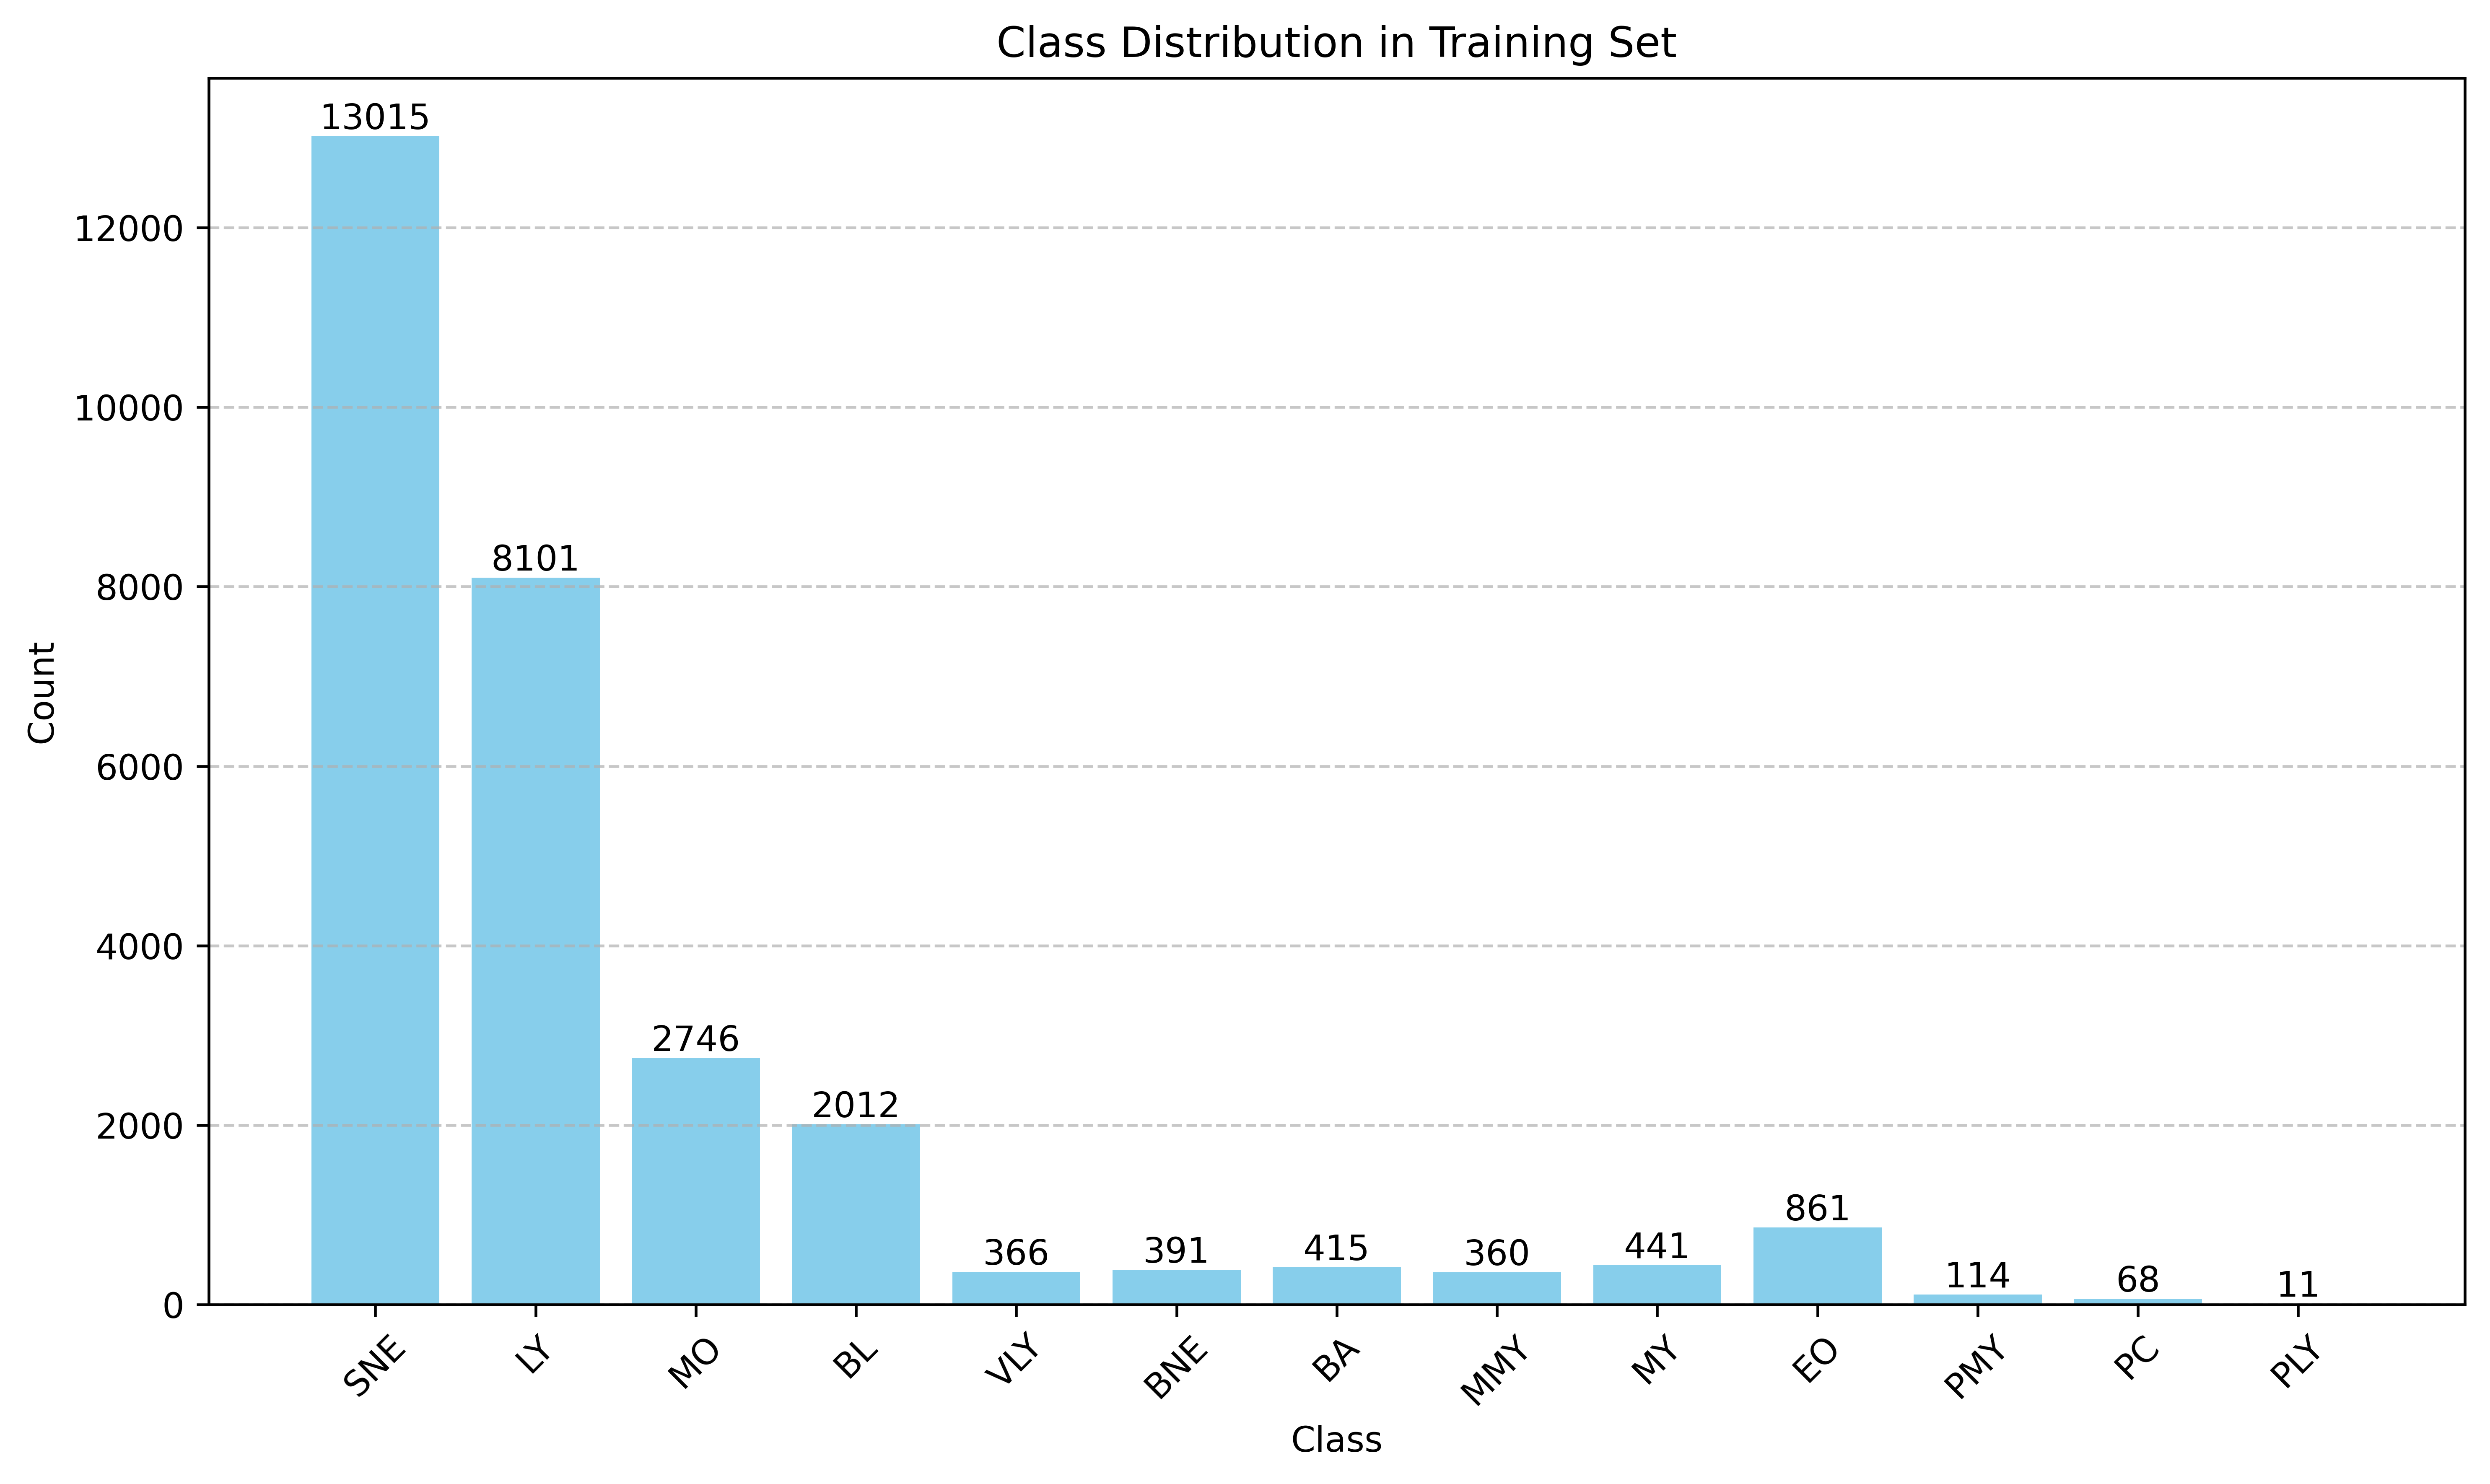

In [15]:
def plot_class_distribution(y: np.ndarray, title: str, label2id: dict):
    counter = Counter(y)
    classes = list(counter.keys())
    counts = list(counter.values())

    id2label = {v: k for k, v in label2id.items()}
    class_names = [id2label[c] for c in classes]

    plt.figure(figsize=(10, 6), dpi=600)
    bars = plt.bar(range(len(classes)), counts, color='skyblue')

    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha='center',
            va='bottom'
        )

    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title(title)
    plt.xticks(range(len(classes)), class_names, rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_class_distribution(y_train, "Class Distribution in Training Set", label2id)

# PREPROCESSING

In [ ]:
def preprocess(img):
    img = cv2.resize(img, (64, 64))

    img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    return lab


def extract_cell_mask(img: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    a = lab[:, :, 1]

    a_blur = cv2.GaussianBlur(a, (5, 5), 0)

    _, mask = cv2.threshold(
        a_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    mask_inv = cv2.bitwise_not(mask)

    if np.sum(mask_inv > 0) > np.sum(mask > 0):
        mask = mask_inv

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        return mask

    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_label = 1 + np.argmax(areas)

    final_mask = np.zeros_like(mask)
    final_mask[labels == largest_label] = 255

    return final_mask


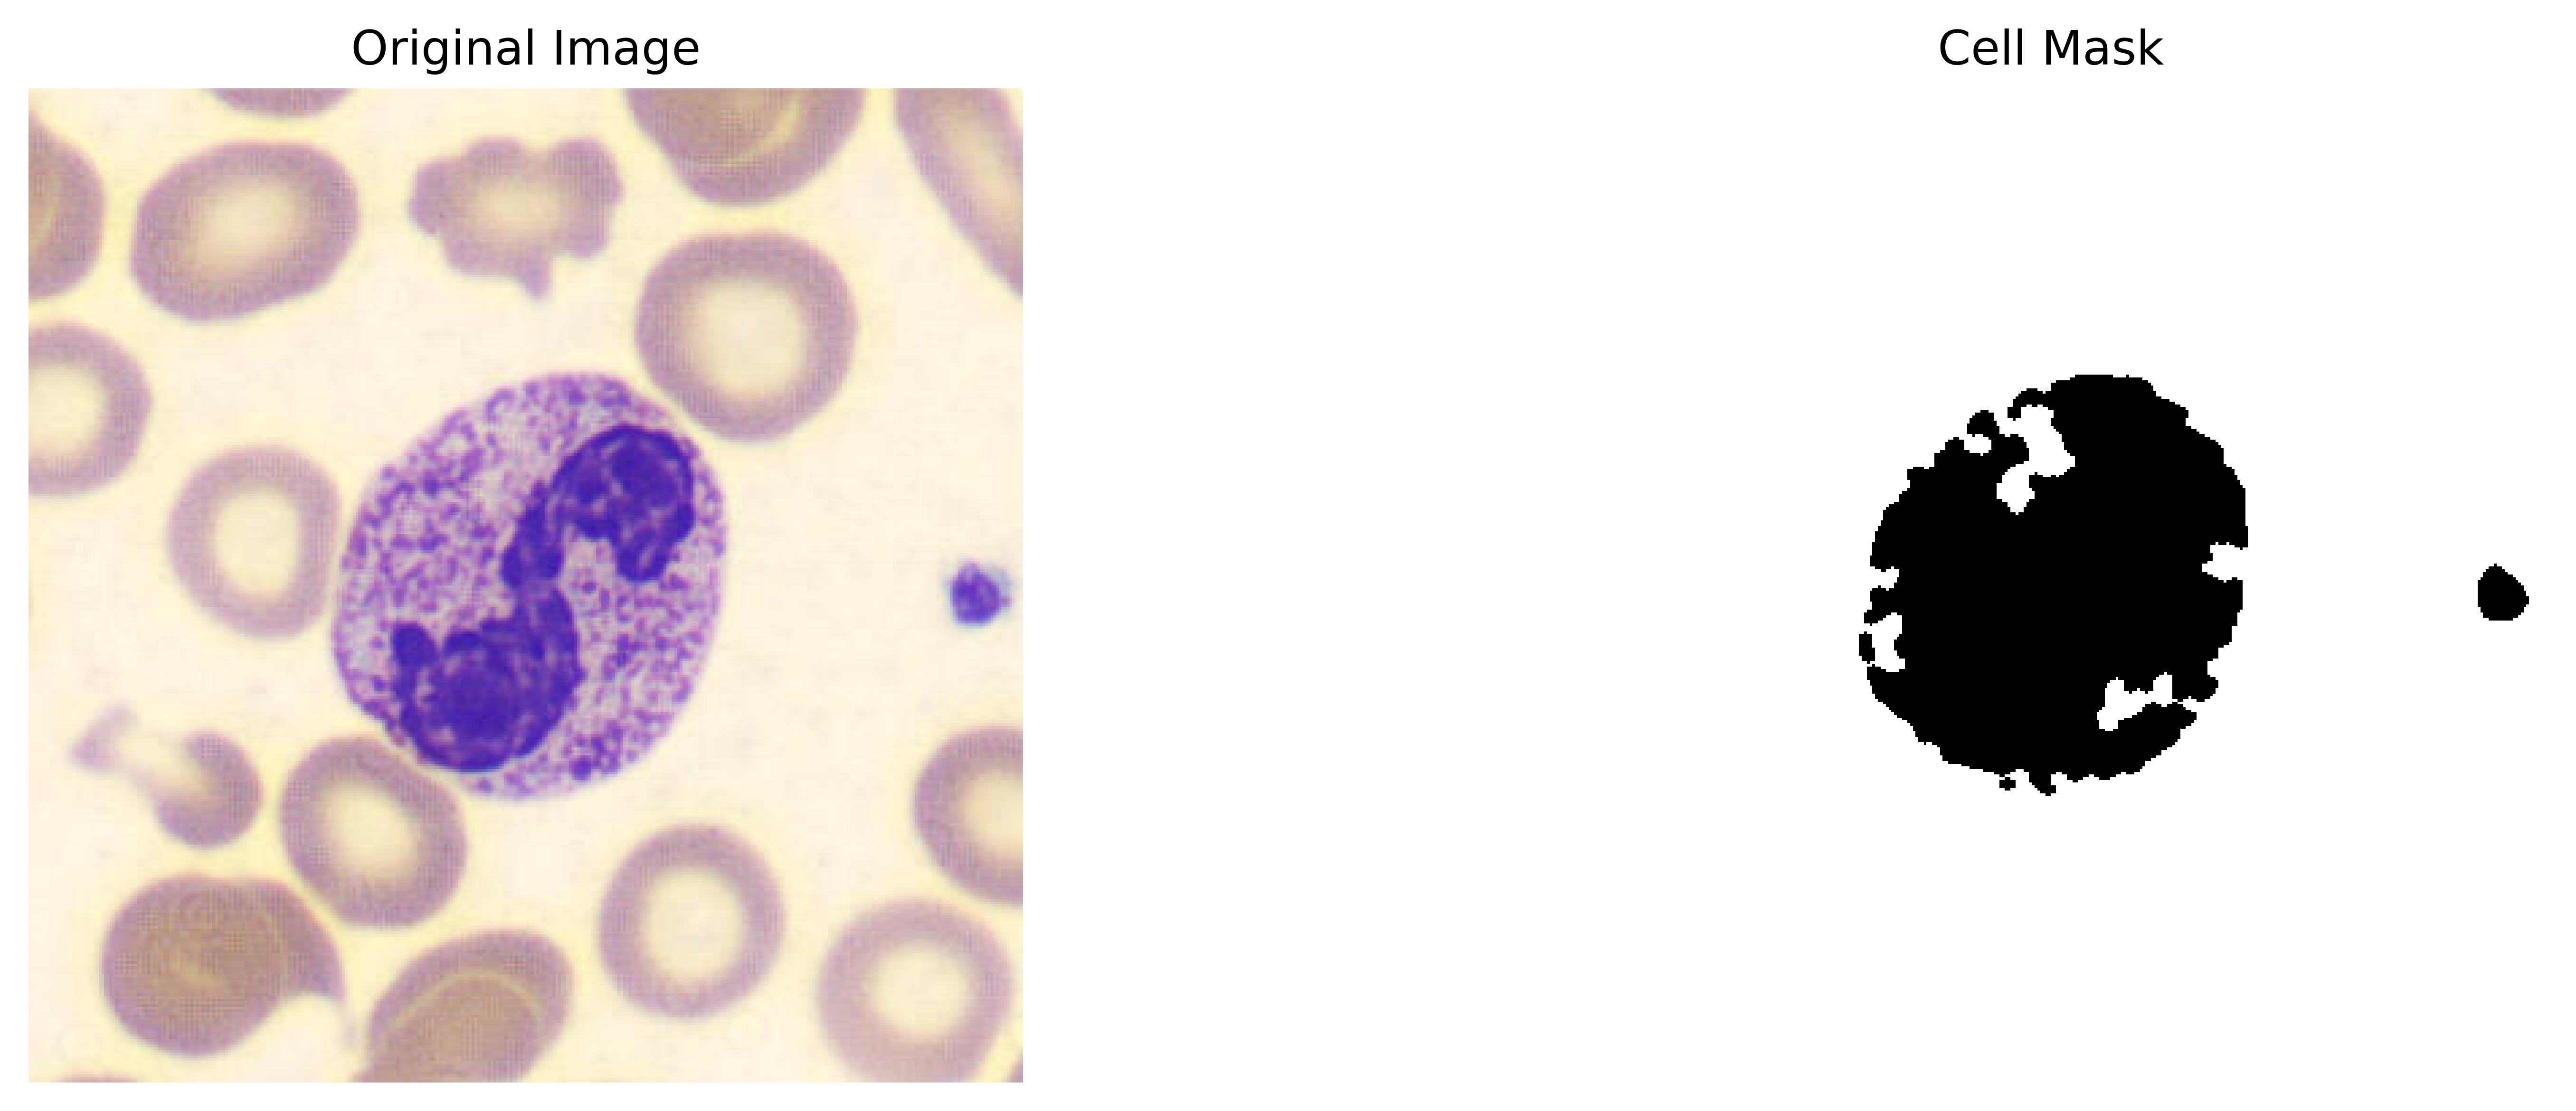

In [24]:
img = X_train[10]
mask = extract_cell_mask(img)


plt.figure(figsize=(12, 4), dpi=600)
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Cell Mask")
plt.axis('off')

plt.tight_layout()
plt.show()  

# FEATURES EXTRACTION

## LOGISTIC REGRESSION

## RANDOM FOREST

## SVM RBF

## XGBOOST